# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

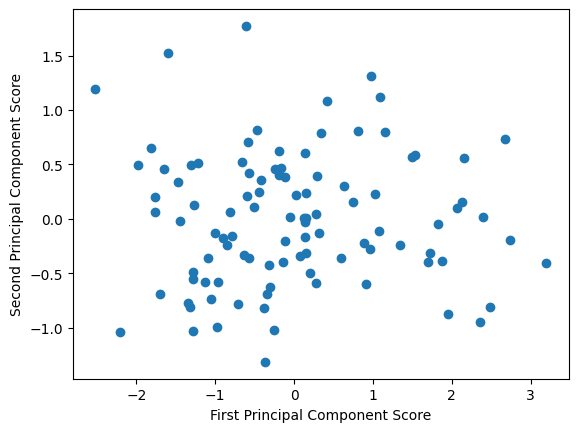

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

In [2]:
SAMPLE_SIZE = 50000 # some of the data sets are large 

def load_csv_sampled(filepath, sample_size=SAMPLE_SIZE, random_state=42, sep=None, encoding=None, **kwargs):
    # try encodings in order
    encodings = [encoding] if encoding else ['utf-8', 'latin-1', 'cp1252']
    
    for enc in encodings:
        try:
            # auto-detect delimiter
            if sep is None:
                with open(filepath, 'r', encoding=enc) as f:
                    first_line = f.readline()
                    sep = '\t' if '\t' in first_line else ','
            
            row_count = sum(1 for _ in open(filepath, encoding=enc)) - 1
            
            if sample_size and row_count > sample_size:
                np.random.seed(random_state)
                skip_idx = np.random.choice(range(1, row_count + 1), size=int(row_count * (1 - sample_size/row_count)), replace=False)
                df = pd.read_csv(filepath, skiprows=skip_idx, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows (sampled from {row_count:,}) [encoding: {enc}]")
            else:
                df = pd.read_csv(filepath, sep=sep, thousands=',', encoding=enc, **kwargs)
                print(f"Loaded {len(df):,} rows [encoding: {enc}]")
            return df
        except UnicodeDecodeError:
            continue
    
    raise ValueError(f"Could not decode file with encodings: {encodings}")

DATASET_US_ECOMM_1 = "data_us_ecommerce_records_sampled"
DATASET_US_ECOMM_2 = "data_ecommerce_behavior_from_multi_category_store_sampled"
DATASET_INSTACART  = "data_instacart_combined_sampled"

df_us_ecomm_1 = load_csv_sampled("data_us_ecommerce_records_sampled.csv")
df_us_ecomm_2 = load_csv_sampled("data_ecommerce_behavior_from_multi_category_store_sampled.csv")
df_instacart  = load_csv_sampled("data_instacart_combined_sampled.csv")



Loaded 3,312 rows [encoding: utf-8]
Loaded 50,000 rows [encoding: utf-8]
Loaded 50,000 rows [encoding: utf-8]


In [5]:
print("\ndata_us_ecommerce_records_sampled \n", df_us_ecomm_1.info())
print("\ndata_ecommerce_behavior_from_multi_category_store_sampled \n", df_us_ecomm_2.info())
print("\ndata_instacart_combined_sampled \n", df_instacart.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3312 entries, 0 to 3311
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    3312 non-null   int64  
 1   Order Date    3312 non-null   object 
 2   Row ID        3312 non-null   int64  
 3   Order ID      3312 non-null   object 
 4   Ship Mode     3312 non-null   object 
 5   Customer ID   3312 non-null   object 
 6   Segment       3312 non-null   object 
 7   Country       3312 non-null   object 
 8   City          3312 non-null   object 
 9   State         3312 non-null   object 
 10  Postal Code   3312 non-null   int64  
 11  Region        3312 non-null   object 
 12  Product ID    3312 non-null   object 
 13  Category      3312 non-null   object 
 14  Sub-Category  3312 non-null   object 
 15  Product Name  3312 non-null   object 
 16  Sales         3312 non-null   float64
 17  Quantity      3312 non-null   int64  
 18  Discount      3312 non-null 

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

### Draw heatmaps

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, numeric_cols=None, title="Correlation Heatmap", figsize=(10, 8)):
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include='number').columns.tolist()
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=14, pad=12)
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

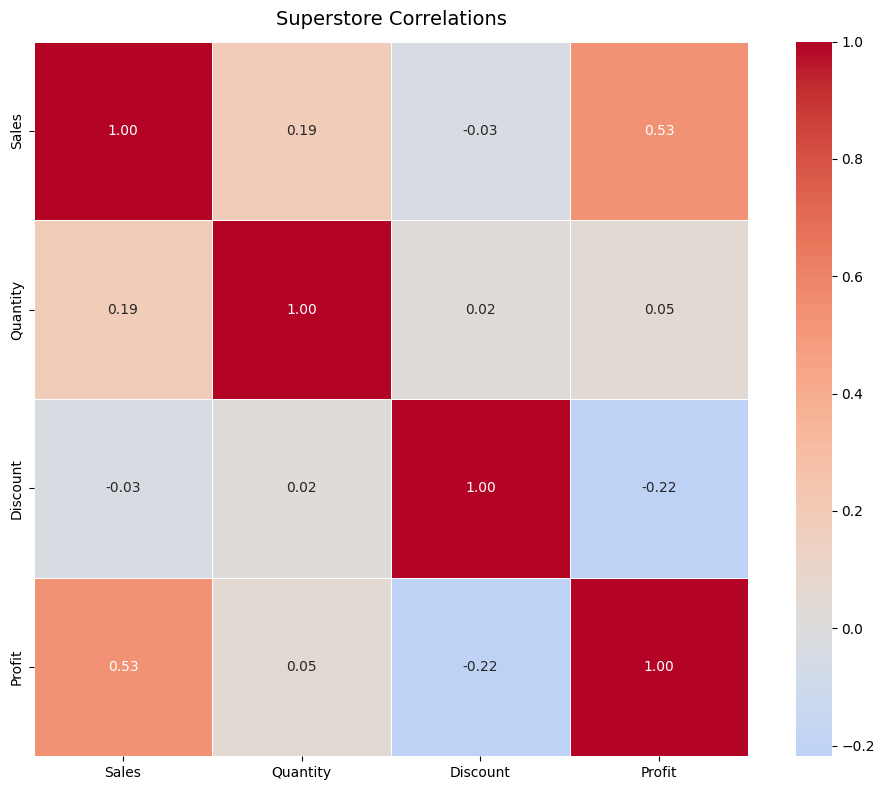

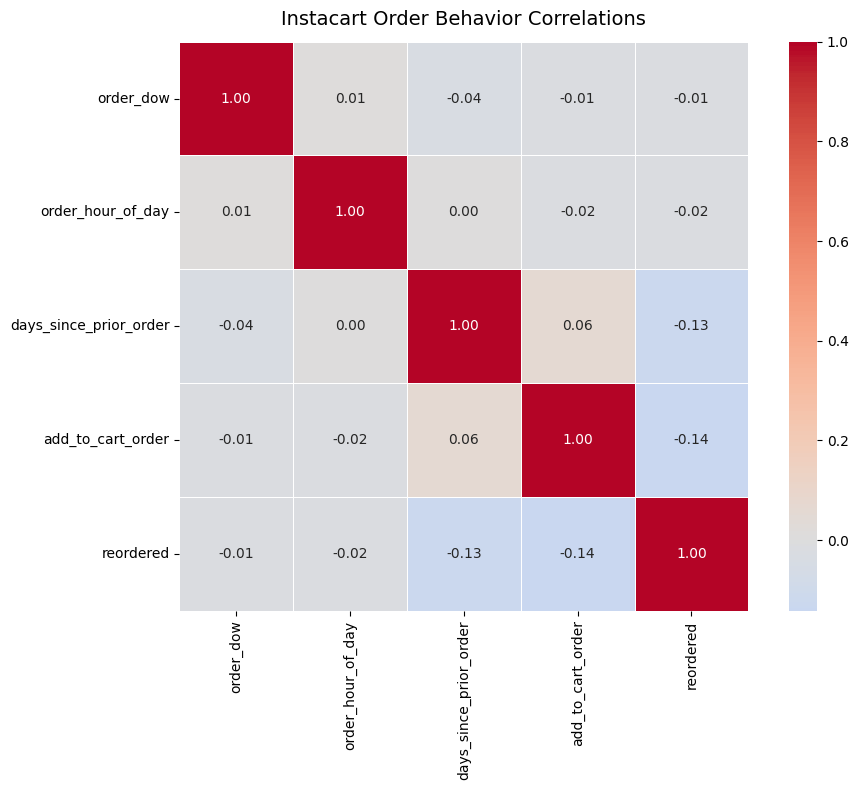

In [8]:

superstore_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr1 = plot_correlation_heatmap(df_us_ecomm_1, superstore_cols,
                                  title="Superstore Correlations")

instacart_cols = ['order_dow', 'order_hour_of_day', 'days_since_prior_order',
                  'add_to_cart_order', 'reordered']
corr2 = plot_correlation_heatmap(df_instacart.dropna(subset=instacart_cols), instacart_cols,
                                  title="Instacart Order Behavior Correlations")


### Draw bubble plots

In [ ]:
def plot_bubble_by_group(df, group_col, value_col, 
                          title="Bubble Plot", figsize=(8, 5), scale=3000):
    grouped = df.groupby(group_col)[value_col].mean().reset_index()
    grouped.columns = [group_col, 'mean_value']

    sizes = grouped['mean_value'].abs() / grouped['mean_value'].abs().max() * scale

    fig, ax = plt.subplots(figsize=figsize)
    scatter = ax.scatter(grouped[group_col], grouped['mean_value'],
                         s=sizes, alpha=0.6,
                         c=grouped['mean_value'], cmap='RdYlGn', edgecolors='black')

    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(group_col)
    ax.set_ylabel(f"Mean {value_col}")
    ax.set_title(title, fontsize=14, pad=12)
    plt.colorbar(scatter, ax=ax, label=f"Mean {value_col}")
    plt.tight_layout()
    plt.show()

    return grouped

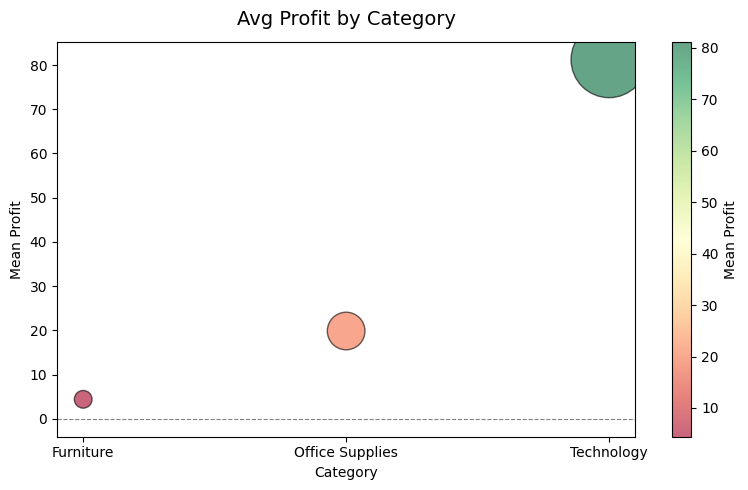

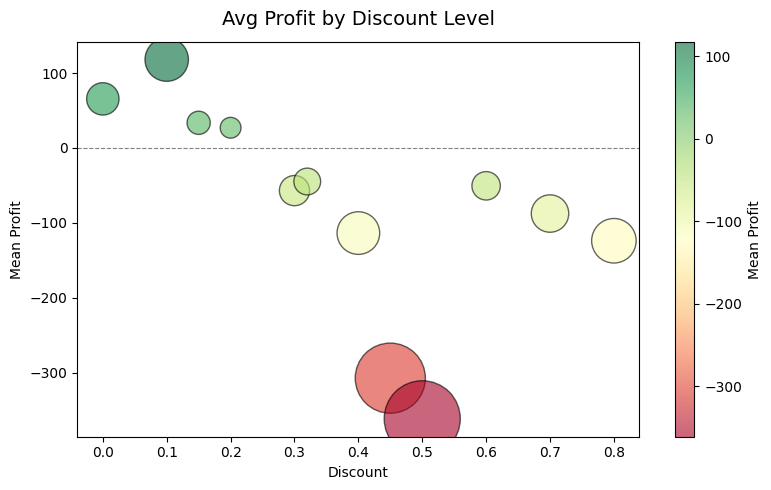

,Discount,mean_value
0,0.00,65.507995
1,0.10,117.878318
2,0.15,33.595806
3,0.20,26.993730
4,0.30,-56.876503
5,0.32,-44.748182
6,0.40,-113.523857
7,0.45,-307.110150
8,0.50,-361.283595
9,0.60,-50.484044


In [13]:
df_superstore = df_us_ecomm_1
plot_bubble_by_group(df_superstore, 
                     group_col='Category', value_col='Profit',
                     title="Avg Profit by Category")

# Profit by Discount level
plot_bubble_by_group(df_superstore,
                     group_col='Discount', value_col='Profit',
                     title="Avg Profit by Discount Level")

### PCA

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

def run_pca(df, numeric_cols, n_components=None, title="PCA Variance Explained", figsize=(8, 5)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[numeric_cols].dropna())

    # Fit PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)

    # Variance explained
    variance_ratio = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(variance_ratio)

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(range(1, len(variance_ratio) + 1), variance_ratio, 
           alpha=0.6, label='Individual')
    ax.step(range(1, len(cumulative_variance) + 1), cumulative_variance, 
            where='mid', color='red', label='Cumulative')
    ax.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, label='90% threshold')
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Variance Explained")
    ax.set_title(title, fontsize=14, pad=12)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Print loadings
    loadings = pd.DataFrame(pca.components_, 
                             columns=numeric_cols,
                             index=[f"PC{i+1}" for i in range(len(variance_ratio))])
    print("\nComponent Loadings:")
    print(loadings.round(3))
    print(f"\nVariance captured by PC1: {variance_ratio[0]:.1%}")
    print(f"Variance captured by PC1+PC2: {cumulative_variance[1]:.1%}")

    return pca, X_pca, loadings

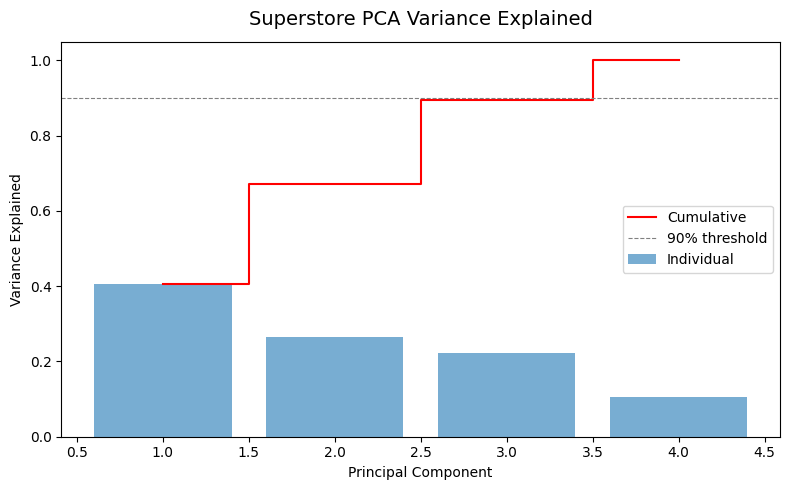


Component Loadings:
     Sales  Quantity  Discount  Profit
PC1  0.654     0.248    -0.259   0.666
PC2  0.198     0.667     0.697  -0.172
PC3 -0.281     0.685    -0.633  -0.226
PC4 -0.674     0.152     0.217   0.690

Variance captured by PC1: 40.7%
Variance captured by PC1+PC2: 67.3%


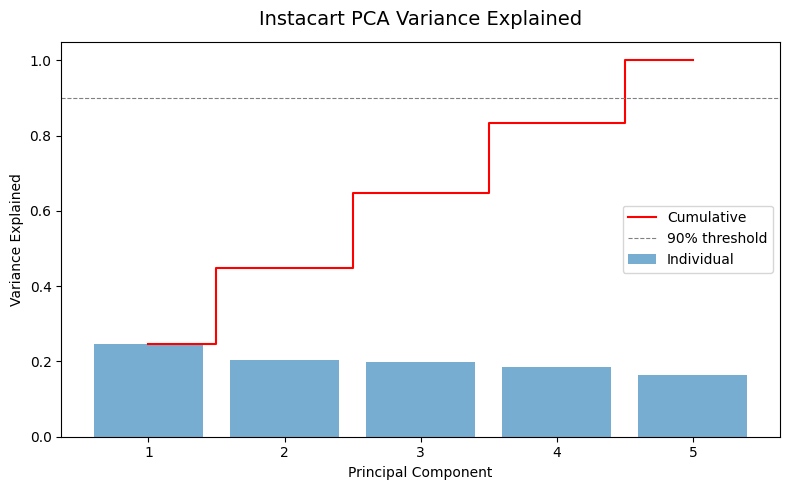


Component Loadings:
     order_dow  order_hour_of_day  days_since_prior_order  add_to_cart_order  \
PC1      0.078             -0.020                  -0.530             -0.544   
PC2      0.723              0.658                  -0.086             -0.054   
PC3     -0.605              0.696                   0.259             -0.276   
PC4      0.271             -0.265                   0.677             -0.631   
PC5      0.179              0.105                   0.431              0.477   

     reordered  
PC1      0.646  
PC2     -0.184  
PC3      0.075  
PC4     -0.016  
PC5      0.737  

Variance captured by PC1: 24.5%
Variance captured by PC1+PC2: 45.0%


In [16]:
# Superstore
pca1, X_pca1, loadings1 = run_pca(
    df_superstore,
    numeric_cols=['Sales', 'Quantity', 'Discount', 'Profit'],
    title="Superstore PCA Variance Explained"
)

# Instacart
pca2, X_pca2, loadings2 = run_pca(
    df_instacart.dropna(subset=['days_since_prior_order']),
    numeric_cols=['order_dow', 'order_hour_of_day', 'days_since_prior_order',
                  'add_to_cart_order', 'reordered'],
    title="Instacart PCA Variance Explained"
)

### Linear regression

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

def run_regression(df, feature_cols, target_col, 
                   title="Linear Regression", figsize=(8, 5)):
    data = df[feature_cols + [target_col]].dropna()
    
    X = data[feature_cols]
    y = data[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                         test_size=0.2, 
                                                         random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2  = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Predicted vs Actual plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(y_test, y_pred, alpha=0.4)
    ax.plot([y_test.min(), y_test.max()], 
            [y_test.min(), y_test.max()], 
            'r--', linewidth=1)
    ax.set_xlabel(f"Actual {target_col}")
    ax.set_ylabel(f"Predicted {target_col}")
    ax.set_title(f"{title}\nR²={r2:.3f}  RMSE={np.sqrt(mse):.2f}", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Coefficients
    coefs = pd.DataFrame({'feature': feature_cols, 
                          'coefficient': model.coef_})\
              .sort_values('coefficient', key=abs, ascending=False)
    print("\nCoefficients:")
    print(coefs.round(4).to_string(index=False))

    return model, coefs, r2

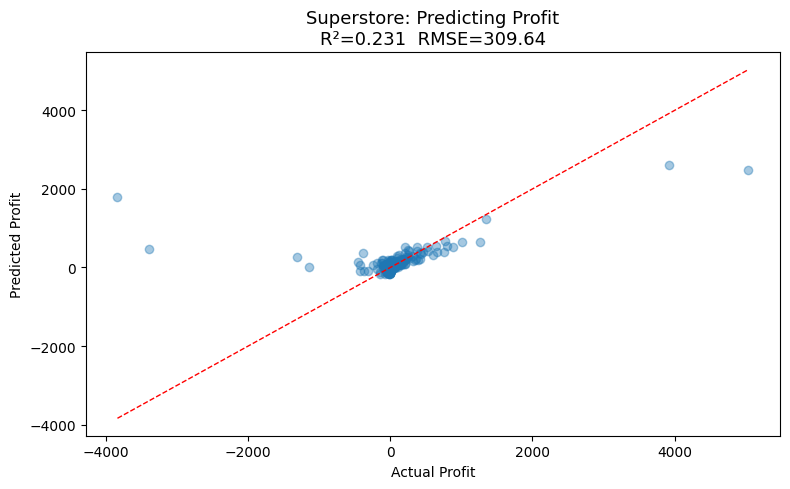


Coefficients:
 feature  coefficient
Discount    -197.4517
Quantity      -5.2245
   Sales       0.2361


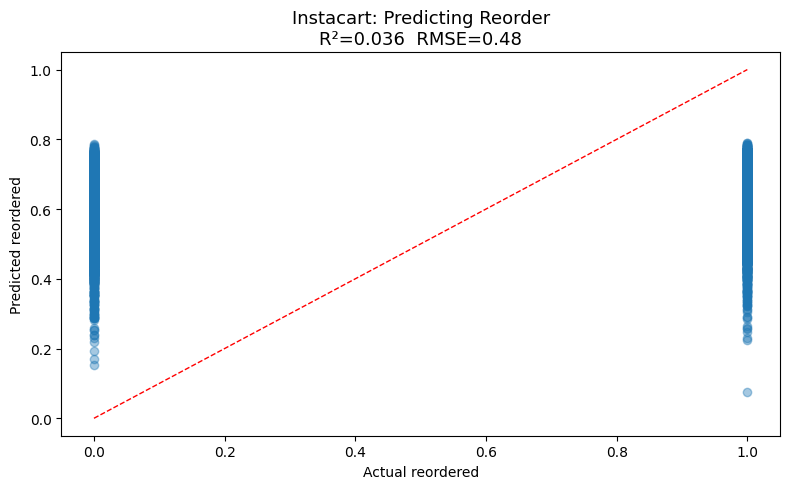


Coefficients:
               feature  coefficient
     add_to_cart_order      -0.0090
days_since_prior_order      -0.0068
             order_dow      -0.0049
     order_hour_of_day      -0.0024


In [19]:
# Superstore — predict Profit from Sales, Quantity, Discount
model1, coefs1, r2_1 = run_regression(
    df_superstore,
    feature_cols=['Sales', 'Quantity', 'Discount'],
    target_col='Profit',
    title="Superstore: Predicting Profit"
)

# Instacart — predict reordered from order behavior
model2, coefs2, r2_2 = run_regression(
    df_instacart.dropna(subset=['days_since_prior_order']),
    feature_cols=['order_dow', 'order_hour_of_day', 
                  'days_since_prior_order', 'add_to_cart_order'],
    target_col='reordered',
    title="Instacart: Predicting Reorder"
)

### Conclusions:

#### Are the data what you expect?
* Superstore behaves as expected — discounting beyond 20% consistently destroys margin. 
* Instacart ordering patterns are consistent with grocery behavior. No surprises in the data.

#### Are the data usable?
* Superstore: yes, clean, no nulls, strong regression signal on Profit.
* Instacart: usable but with caveats — reordered is binary so linear regression undersells what the data can do. The dataset is better suited for association analysis in the milestone than regression here.
#### Outliers?
* Superstore has visible outliers — high-value Technology items with large Sales but negative Profit at 50%+ discounts. These are worth flagging as they disproportionately skew the regression.
### PCA conclusion?
* PC1 alone is insufficient — it captures roughly 45-50% of variance, meaning ~50% of information is lost. Two components together tell a more complete story, but even then compression has a cost for decision making.


### Note 
* Bridge to milestone:
   * Instacart's add_to_cart_order and reordered columns together reveal purchasing intentionality — a foundation for identifying recommendation candidates at checkout, which is the core milestone question.
* Dataset 3 — E-commerce Clickstream (not used in this analysis)
The clickstream dataset tracks user events (view, cart, purchase) at the product level across sessions. It was excluded from this week's analysis as PCA and linear regression are difficult to apply meaningfully to event-type data without feature engineering. However it is the most promising dataset for the milestone. Each user session contains an implicit sequence of product interactions that can be used to build product association rules. A customer who views product A then purchases product B in the same session is a signal those products are related. Across thousands of sessions those signals become recommendation candidates. The dataset will be revisited in the milestone for association-based analysis.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

Trying for Chart on Page 144

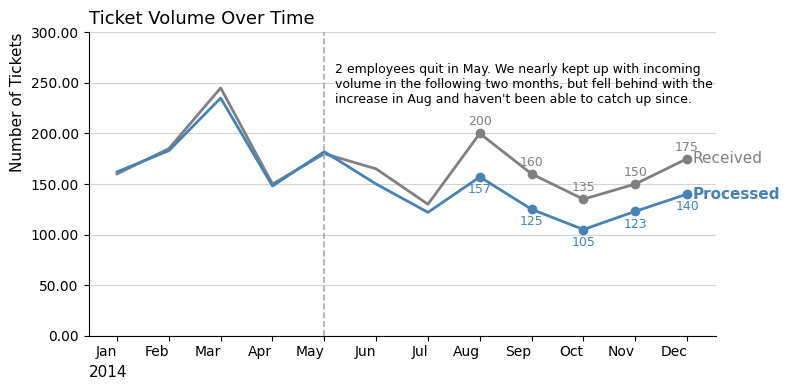

In [37]:
months = ['January', 'February', 'March', 'April', 'May', 'June',
          'July', 'August', 'September', 'October', 'November', 'December']

df_fake = pd.DataFrame({
    'month': months,
    
    'received':     [160, 185, 245, 150, 180, 165, 130, 200, 160, 135, 150, 175],
    'processed': [162, 183, 235, 148, 182, 150, 122, 157, 125, 105, 123, 140]
})
fig, ax = plt.subplots(figsize=(8, 4), facecolor='white')

received_color = 'gray'
processed_color = 'steelblue'
linewidth = 2

ax.plot(df_fake.index, df_fake['received'], 
       label='Ticket Volume Received', color=received_color, linewidth=linewidth)
ax.plot(df_fake.index, df_fake['processed'], 
       label='Ticket Volume Processed', color=processed_color, linewidth=linewidth)

for i in range(7, 12):
    ax.plot(i, df_fake['received'].iloc[i], marker='o', color=received_color, markersize=6)
    ax.plot(i, df_fake['processed'].iloc[i], marker='o', color=processed_color, markersize=6)
    ax.text(i, df_fake['received'].iloc[i]  + 8, str(df_fake['received'].iloc[i]),  
            ha='center', fontsize=9, color=received_color)
    ax.text(i, df_fake['processed'].iloc[i] - 16, str(df_fake['processed'].iloc[i]), 
            ha='center', fontsize=9, color=processed_color)

ax.set_facecolor('white')
ax.grid(axis='y', color='lightgray', linewidth=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)

ax.set_xticks(range(len(df_fake)))
ax.set_xticklabels(df_fake['month'].str[:3], ha='right')


# series labels at end of lines
ax.text(11.1, df_fake['received'].iloc[-1],  'Received',  fontsize=11, color=received_color,    va='center')
ax.text(11.1, df_fake['processed'].iloc[-1], 'Processed', fontsize=11, color=processed_color, va='center', fontweight='bold')


ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
ax.set_ylim(bottom=0, top=300)

# 1. Axis titles
ax.set_xlabel("2014", fontsize=11, loc='left')
ax.set_ylabel("Number of Tickets", fontsize=11, loc='top')
ax.set_title("Ticket Volume Over Time", fontsize=13, loc='left' )

# 2. Vertical line at May (index 4)
ax.axvline(x=4, color='darkgray', linestyle='--', linewidth=1.2)

# 3. Annotation
ax.annotate(
    "2 employees quit in May. We nearly kept up with incoming\n"
    "volume in the following two months, but fell behind with the\n"
    "increase in Aug and haven't been able to catch up since.",
    xy=(4, 260),
    xytext=(4.2, 270),
    fontsize=9,
    color='black',
    verticalalignment='top'
)

plt.tight_layout()
plt.show()